<a href="https://colab.research.google.com/github/xwu23-max/BASC0080-Group-Project/blob/main/Monte_Carlo%20for%20European_Call%26Arithmetic_Asian_Call.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from time import time

In [ ]:
S0 = 6672.62 # Initial stock price
K = 6675 # Strike price
T = 0.5 # Time to maturity (in years)
r = 0.0354 # Risk-free interest rate
q = 0.011 # Dividend yield
sigma = 0.181223 # Volatility
M = 50 # Number of time steps
dt = T/M # Time step length
I = 50000 # Number of simulation paths

In [ ]:
def mc_european_call_once(S0, r, q, sigma, T, M, I, K):
    Z = np.random.standard_normal((M, I))
    S = S0 * np.exp(np.cumsum(((r-q) - 0.5 * sigma**2) * dt
                                     + sigma * math.sqrt(dt) * Z, axis=0))
    payoff = np.maximum(S[-1] - K, 0.0)
    return math.exp(-r * T) * np.mean(payoff)

def mc_european_call(S0, r, q, sigma, T, M, I, K, N_reps=50, base_seed=20000):
    prices = []
    for rep in range(N_reps):
        np.random.seed(base_seed + rep)
        price = mc_european_call_once(S0, r, q, sigma, T, M, I, K)
        prices.append(price)
    prices = np.array(prices)
    mean_price = prices.mean()
    std_price = prices.std(ddof=1)
    se = std_price / np.sqrt(N_reps)
    ci_low = mean_price - 1.96 * se
    ci_high = mean_price + 1.96 * se
    print(f"reps={N_reps} Call price={mean_price:.4f}  CI(95%)=[{ci_low:.4f}, {ci_high:.4f}]")
    return mean_price, ci_low, ci_high

In [ ]:
mc_european_call(S0, r, q, sigma, T, M, I, K, N_reps=50, base_seed=20000)

reps=50 Call price=377.1368  CI(95%)=[376.6047, 377.6690]


(np.float64(377.1368477635635),
 np.float64(376.604735560854),
 np.float64(377.66895996627295))

In [ ]:
t0 = time ()
np. random.seed (20000)
t1 = time ()
print(f"Stock Price Simulation Completed in {t1 - t0:.2f} seconds")
price = mc_european_call_once(S0, r, q, sigma, T, M, I, K)
print(f"European Call Option Value: {price:.3f}")

Stock Price Simulation Completed in 0.00 seconds
European Call Option Value: 380.064


In [ ]:
def mc_arithmetic_asian_call_once(S0, r, q, sigma, T, M, I, K):
    dt = T / M
    Z = np.random.standard_normal((M, I))
    S = S0 * np.exp(np.cumsum(((r - q) - 0.5 * sigma**2) * dt
            + sigma * math.sqrt(dt) * Z, axis=0))
    S_avg = np.mean(S, axis=0)   # excludes S0
    payoff = np.maximum(S_avg - K, 0.0)
    return math.exp(-r * T) * np.mean(payoff)

# Repeated runs with confidence interval
def mc_option_repeated(pricer_once, S0, r, q, sigma, T, M, I, K, N_reps=50, base_seed=20000):
    prices = []
    for rep in range(N_reps):
        np.random.seed(base_seed + rep)
        price = pricer_once(S0, r, q, sigma, T, M, I, K)
        prices.append(price)
    prices = np.array(prices)
    mean_price = prices.mean()
    std_price = prices.std(ddof=1)
    se = std_price / np.sqrt(N_reps)
    ci_low = mean_price - 1.96 * se
    ci_high = mean_price + 1.96 * se
    print(f"Arithmetic Asian Call: reps={N_reps}, price={mean_price:.4f}, CI(95%)=[{ci_low:.4f}, {ci_high:.4f}]")
    return mean_price, ci_low, ci_high

In [ ]:
mc_option_repeated(mc_arithmetic_asian_call_once, S0, r, q, sigma, T, M, I, K)

Arithmetic Asian Call: reps=50, price=216.8133, CI(95%)=[216.4767, 217.1498]


(np.float64(216.81327907404597),
 np.float64(216.47671621865206),
 np.float64(217.14984192943987))

In [ ]:
# Add initial stock price for better visualization
S_with_initial = np.vstack((np.full((1, I), S0), S))

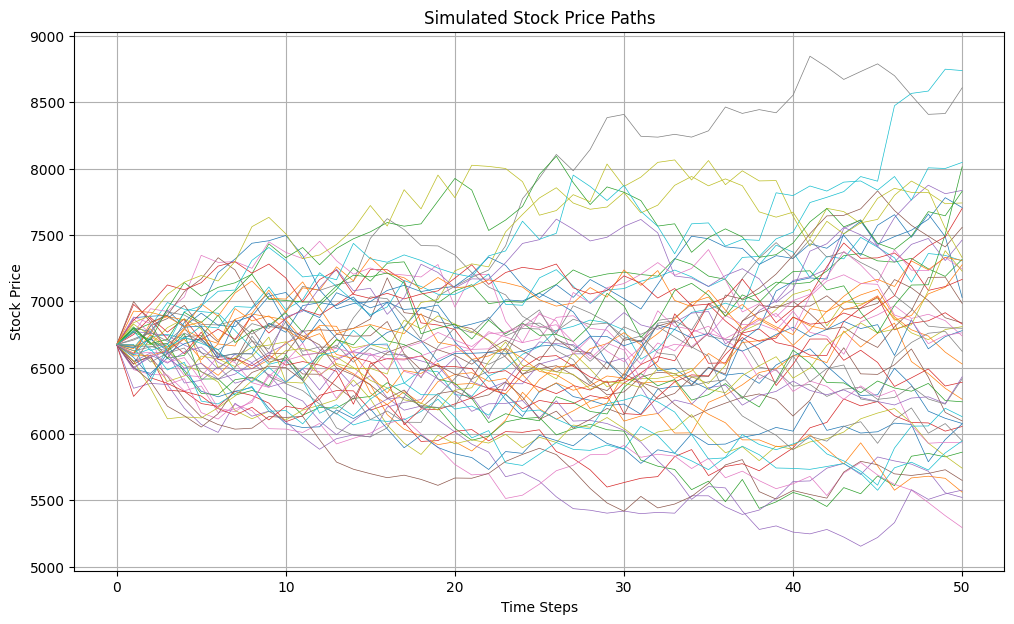

In [ ]:
# Plot a subset of the simulated paths
plt.figure (figsize=(12, 7))
plt.plot(S_with_initial[:, ::1000], linewidth=0.5)
plt.grid(True)
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.title("Simulated Stock Price Paths")
plt.show()

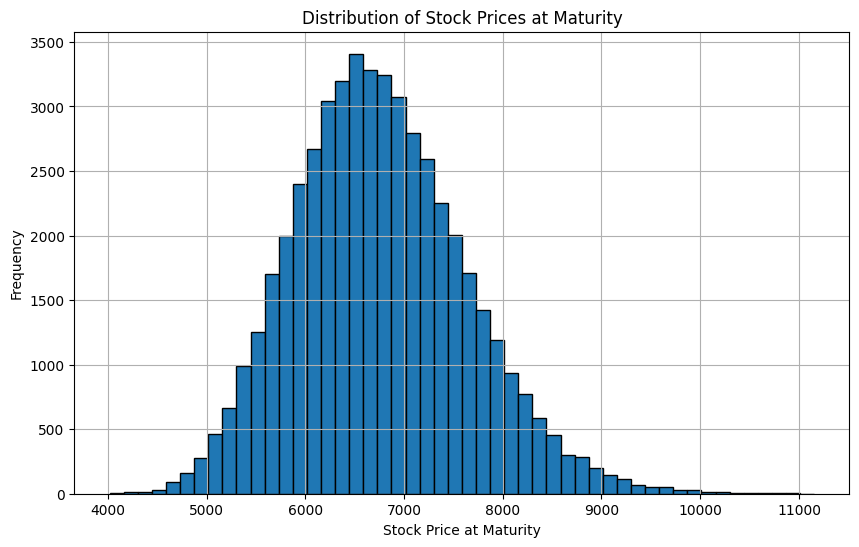

In [ ]:
# Plot histogram of stock prices at maturity
plt. figure (figsize=(10, 6))
plt.hist(S[-1], bins=50, edgecolor='black')
plt.grid(True)
plt.xlabel("Stock Price at Maturity")
plt.ylabel("Frequency")
plt.title("Distribution of Stock Prices at Maturity")
plt.show()

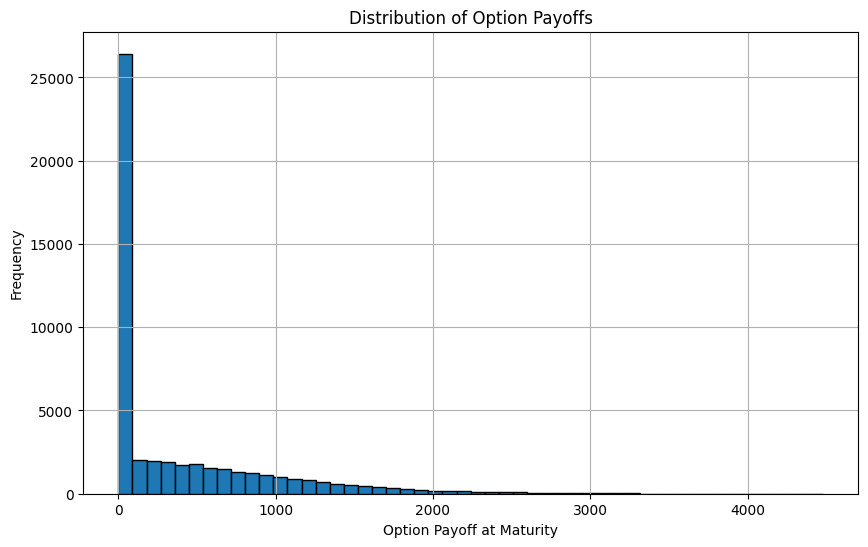

In [ ]:
#Plot histogram of option payoffs at maturity
plt.figure(figsize=(10, 6))
plt.hist(payoffs, bins=50, edgecolor='black')
plt.grid(True)
plt.xlabel("Option Payoff at Maturity")
plt.ylabel("Frequency")
plt.title("Distribution of Option Payoffs")
plt.show()